In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/cyclone_daily_1891_2025.csv")

df.head()

,DATE,YEAR,MONTH,DAY,cyclones_total,max_wind,severe_total,disturbances_total,severity_ratio,disturbance_ratio,target,cyclone_5yr_avg,season_monsoon,season_post_monsoon,season_pre_monsoon,season_winter,cyclones_prev_day,cyclones_prev_3d,cyclones_prev_7d
0,1891-01-01,1891,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,False,False,False,True,NaN,NaN,NaN
1,1891-01-02,1891,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,False,False,False,True,0.0,NaN,NaN
2,1891-01-03,1891,1,3,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,False,False,False,True,0.0,0.0,NaN
3,1891-01-04,1891,1,4,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,False,False,False,True,0.0,0.0,NaN
4,1891-01-05,1891,1,5,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,False,False,False,True,0.0,0.0,NaN


In [3]:
df["DATE"] = pd.to_datetime(df["DATE"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49308 entries, 0 to 49307
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE                 49308 non-null  datetime64[ns]
 1   YEAR                 49308 non-null  int64         
 2   MONTH                49308 non-null  int64         
 3   DAY                  49308 non-null  int64         
 4   cyclones_total       49308 non-null  float64       
 5   max_wind             49308 non-null  float64       
 6   severe_total         49308 non-null  float64       
 7   disturbances_total   49308 non-null  float64       
 8   severity_ratio       49308 non-null  float64       
 9   disturbance_ratio    49308 non-null  float64       
 10  target               49308 non-null  int64         
 11  cyclone_5yr_avg      7279 non-null   float64       
 12  season_monsoon       49308 non-null  bool          
 13  season_post_monsoon  49308 non-

In [4]:
df.describe()

,DATE,YEAR,MONTH,DAY,cyclones_total,max_wind,severe_total,disturbances_total,severity_ratio,disturbance_ratio,target,cyclone_5yr_avg,cyclones_prev_day,cyclones_prev_3d,cyclones_prev_7d
count,49308,49308.000000,49308.000000,49308.000000,49308.000000,49308.000000,49308.000000,49308.000000,49308.000000,49308.000000,49308.000000,7279.000000,49307.000000,49306.000000,49302.000000
mean,1958-07-02 12:00:00,1958.001176,6.522998,15.729435,0.158047,1.476049,0.032875,0.316095,0.015380,0.151032,0.005537,1.060744,0.158051,0.158054,0.158067
min,1891-01-01 00:00:00,1891.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1924-10-01 18:00:00,1924.000000,4.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.035068,0.000000,0.000000,0.000000
50%,1958-07-02 12:00:00,1958.000000,7.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.060274,0.000000,0.000000,0.000000
75%,1992-04-01 06:00:00,1992.000000,10.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.087123,0.000000,0.000000,0.142857
max,2025-12-31 00:00:00,2025.000000,12.000000,31.000000,4.000000,150.000000,16.000000,8.000000,5.333333,1.600000,1.000000,1.106849,4.000000,3.000000,2.857143
std,NaN,38.970178,3.448719,8.800096,0.393359,9.161897,0.493487,0.786718,0.229137,0.364420,0.074203,0.029748,0.393362,0.356010,0.304550


In [5]:
df["target"].value_counts()

target
0    49035
1      273
Name: count, dtype: int64

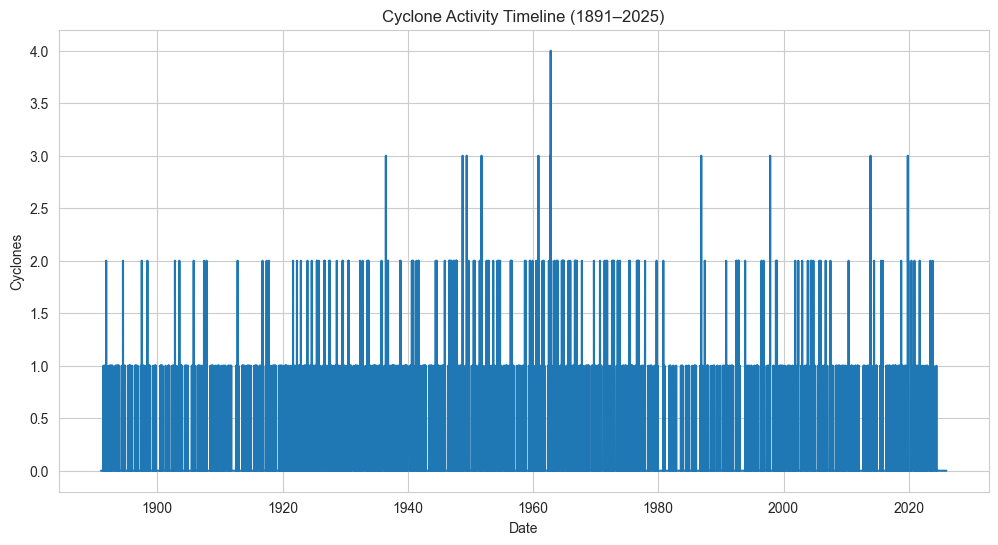

In [6]:
plt.figure(figsize=(12,6))

plt.plot(df["DATE"], df["cyclones_total"])

plt.title("Cyclone Activity Timeline (1891–2025)")
plt.xlabel("Date")
plt.ylabel("Cyclones")

plt.show()

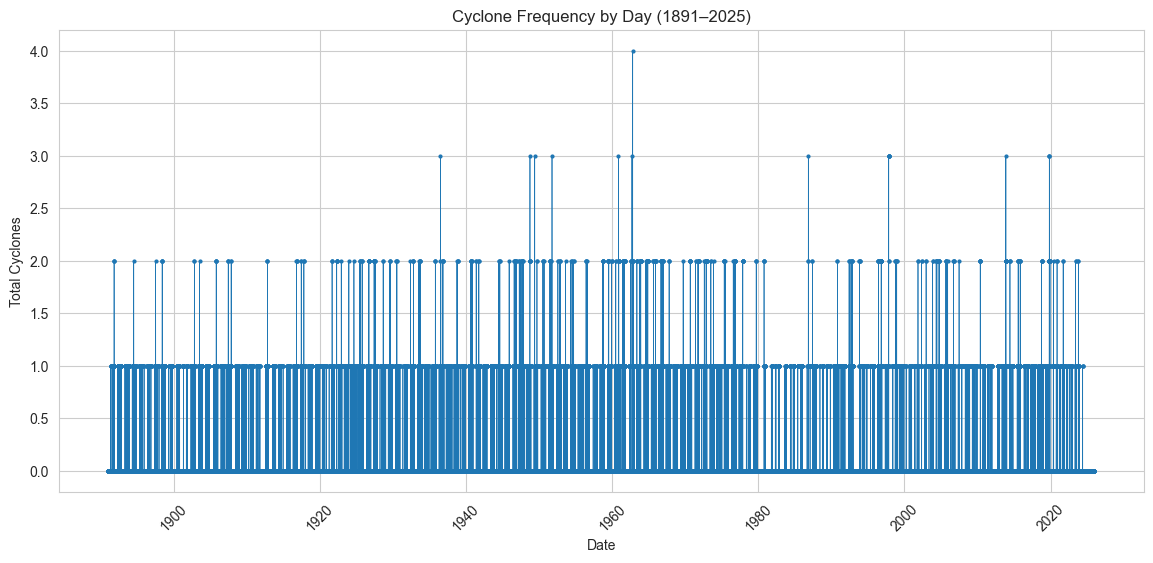

In [7]:
plt.figure(figsize=(14,6))

plt.plot(df["DATE"], df["cyclones_total"], marker="o", markersize=2, linestyle="-", linewidth=0.5)

plt.title("Cyclone Frequency by Day (1891–2025)")
plt.xlabel("Date")
plt.ylabel("Total Cyclones")
plt.xticks(rotation=45)

plt.show()

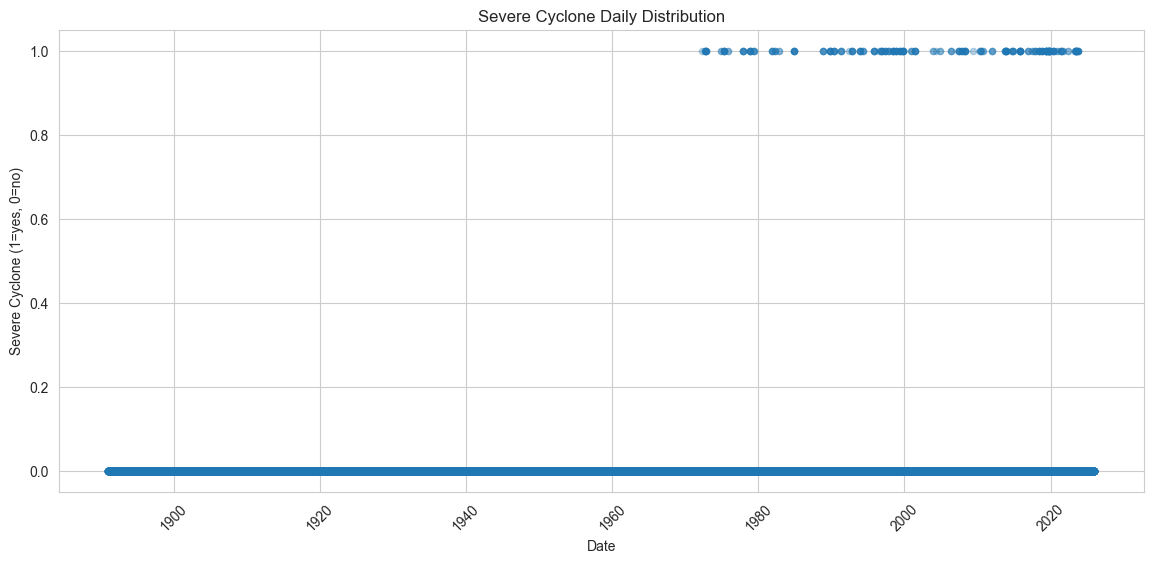

In [8]:
plt.figure(figsize=(14,6))

plt.scatter(df["DATE"], df["target"], alpha=0.3, s=20)

plt.title("Severe Cyclone Daily Distribution")
plt.xlabel("Date")
plt.ylabel("Severe Cyclone (1=yes, 0=no)")
plt.xticks(rotation=45)

plt.show()

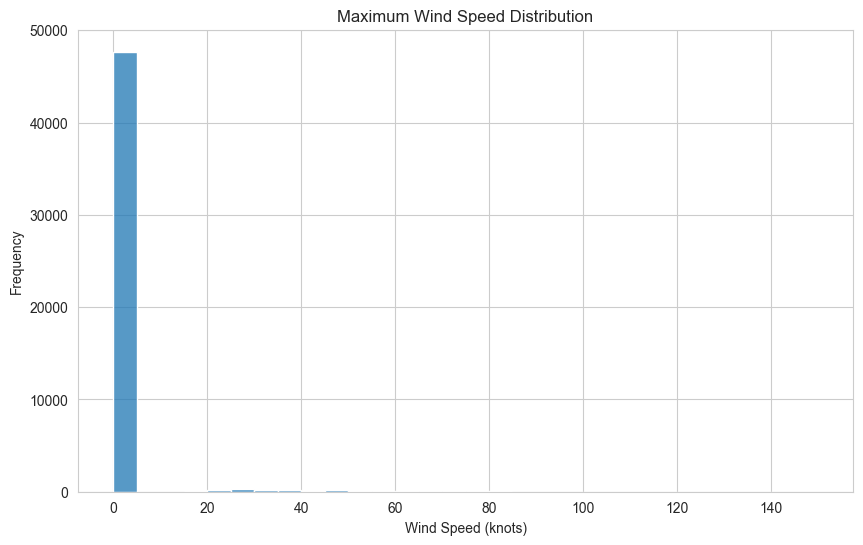

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(df["max_wind"], bins=30)

plt.title("Maximum Wind Speed Distribution")
plt.xlabel("Wind Speed (knots)")
plt.ylabel("Frequency")

plt.show()

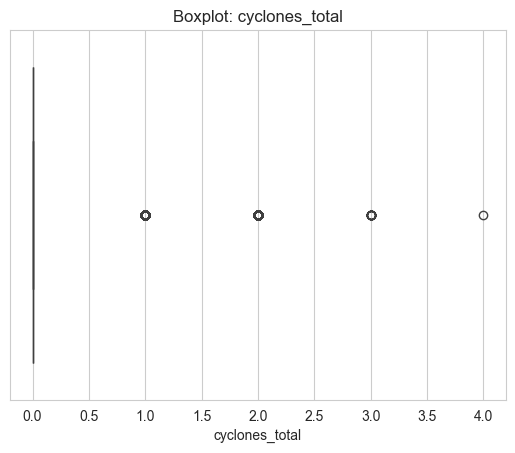

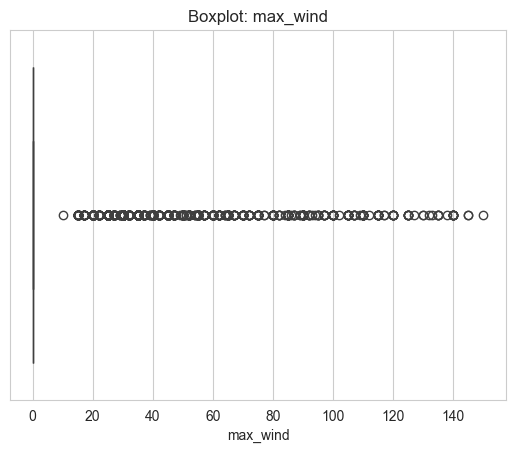

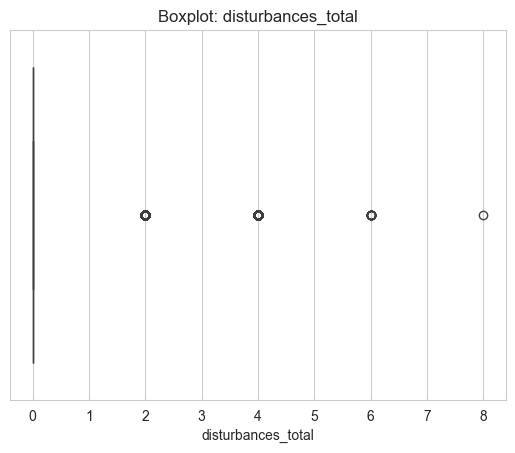

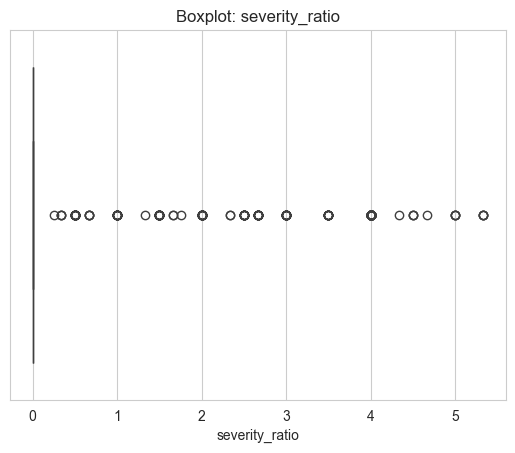

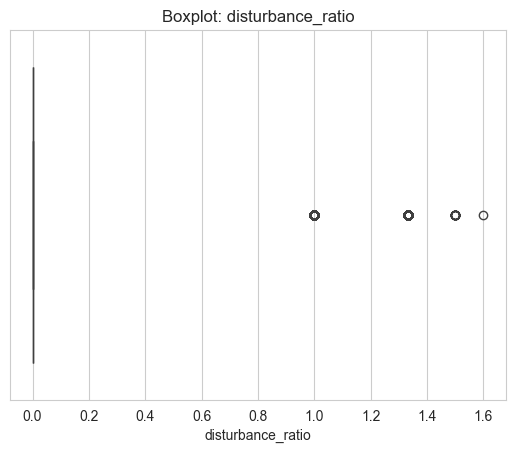

In [10]:
features = [
    "cyclones_total",
    "max_wind",
    "disturbances_total",
    "severity_ratio",
    "disturbance_ratio"
]

for f in features:
    
    plt.figure()
    
    sns.boxplot(x=df[f])
    
    plt.title(f"Boxplot: {f}")
    
    plt.show()

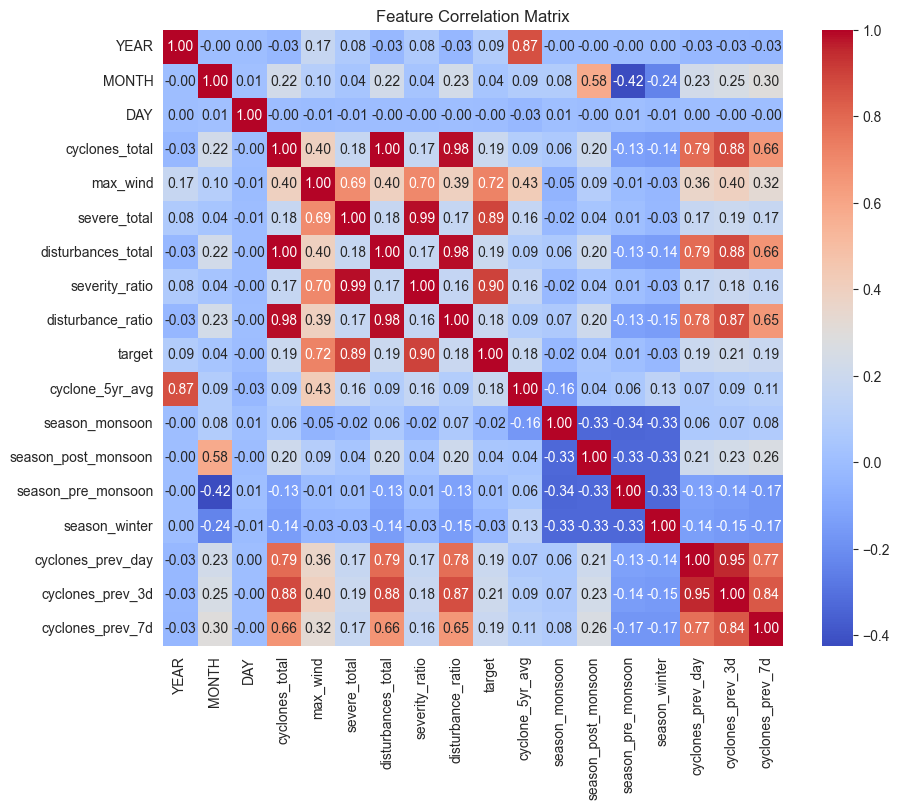

In [11]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

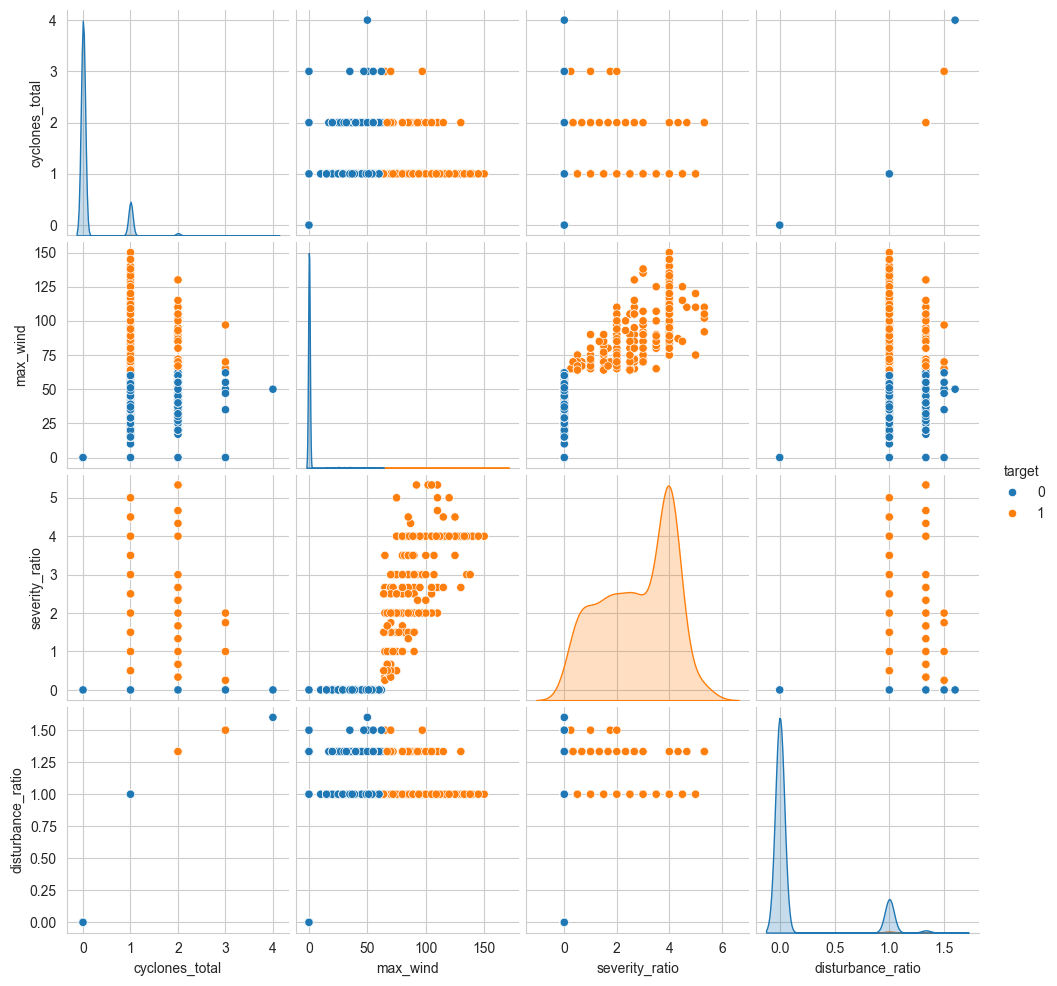

In [12]:
sns.pairplot(
    df[
        [
            "cyclones_total",
            "max_wind",
            "severity_ratio",
            "disturbance_ratio",
            "target"
        ]
    ],
    hue="target"
)

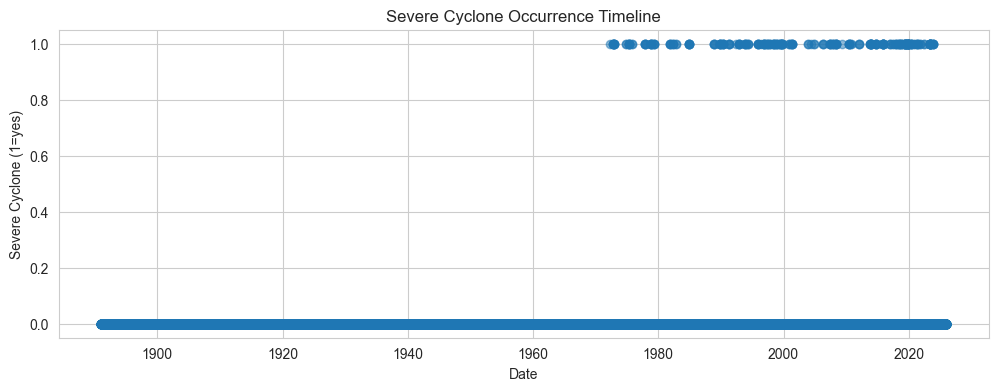

In [13]:
plt.figure(figsize=(12,4))

plt.scatter(
    df["DATE"],
    df["target"],
    alpha=0.5
)

plt.title("Severe Cyclone Occurrence Timeline")
plt.xlabel("Date")
plt.ylabel("Severe Cyclone (1=yes)")

plt.show()

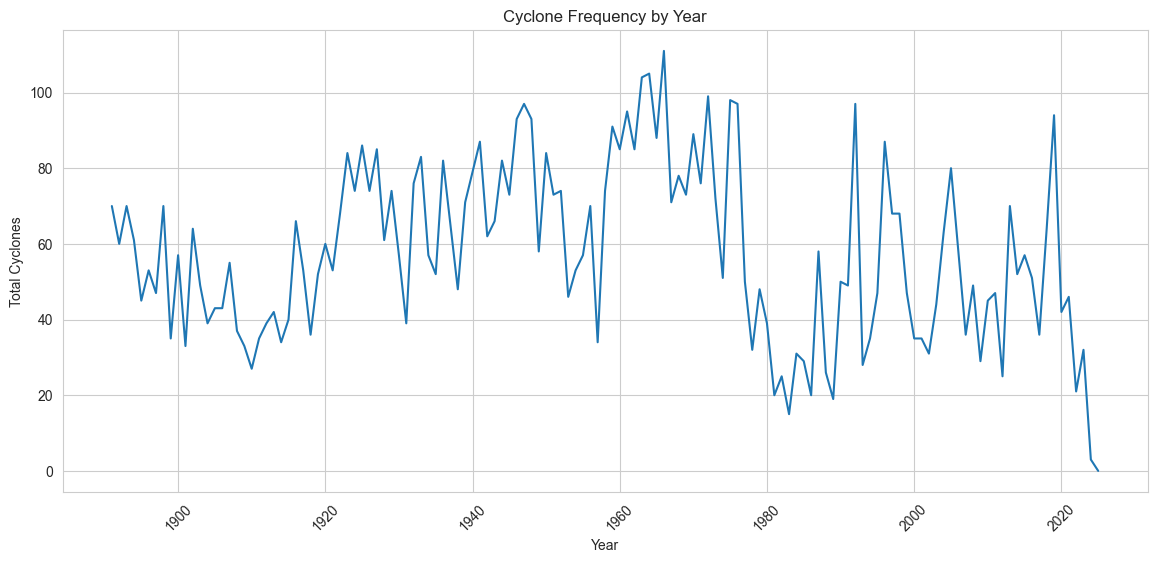

In [14]:
df["year"] = df["YEAR"]

yearly_counts = df.groupby("year")["cyclones_total"].sum()

plt.figure(figsize=(14,6))
yearly_counts.plot(kind="line")

plt.title("Cyclone Frequency by Year")
plt.xlabel("Year")
plt.ylabel("Total Cyclones")
plt.xticks(rotation=45)

plt.show()

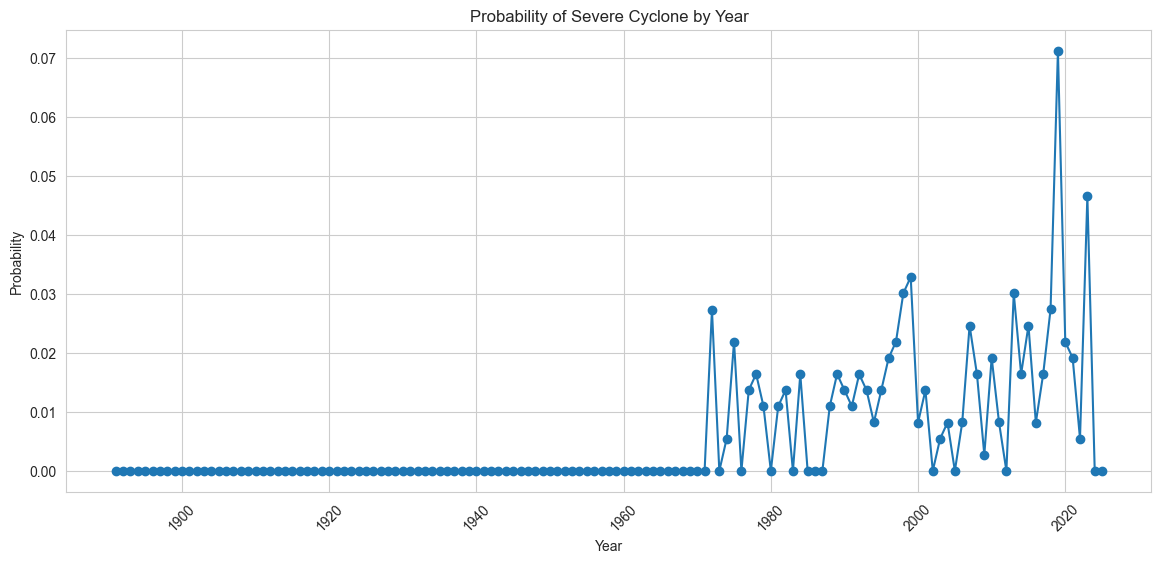

In [15]:
yearly_prob = df.groupby("year")["target"].mean()

plt.figure(figsize=(14,6))
yearly_prob.plot(kind="line", marker="o")

plt.title("Probability of Severe Cyclone by Year")
plt.xlabel("Year")
plt.ylabel("Probability")
plt.xticks(rotation=45)

plt.show()

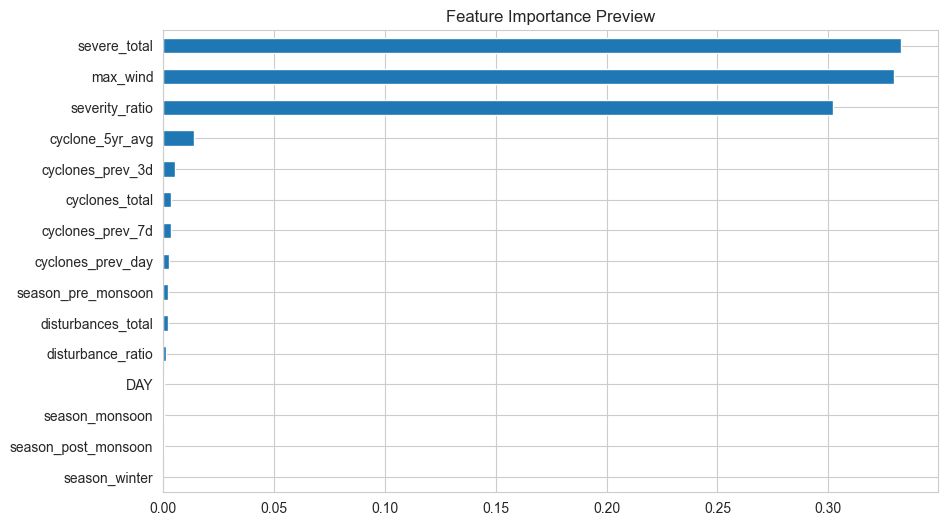

In [16]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["target","DATE","YEAR","MONTH","year"])
y = df["target"]

rf = RandomForestClassifier(random_state=42)

rf.fit(X,y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot.barh(figsize=(10,6))

plt.title("Feature Importance Preview")

plt.show()

In [17]:
drop_cols = [
    "YEAR",
    "MONTH",
    "max_wind",
    "severe_total",
    "severity_ratio"
]
df = df.drop(columns=drop_cols)
df["cyclone_5yr_avg"] = df["cyclone_5yr_avg"].fillna(method="bfill")
df = df.fillna(0)

X = df.drop(columns=["target", "DATE"])
y = df["target"]

C:\Users\SAMADRITA KARMAKAR\AppData\Local\Temp\ipykernel_1220\3397529751.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["cyclone_5yr_avg"] = df["cyclone_5yr_avg"].fillna(method="bfill")


In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [20]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(34515, 13)
(7396, 13)
(7397, 13)


In [21]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

In [22]:
joblib.dump(X_train_scaled,"../features/X_train.pkl")
joblib.dump(X_val_scaled,"../features/X_val.pkl")
joblib.dump(X_test_scaled,"../features/X_test.pkl")

joblib.dump(y_train,"../features/y_train.pkl")
joblib.dump(y_val,"../features/y_val.pkl")
joblib.dump(y_test,"../features/y_test.pkl")

joblib.dump(scaler,"../features/scaler.pkl")

['../features/scaler.pkl']

In [23]:
df.columns

Index(['DATE', 'DAY', 'cyclones_total', 'disturbances_total',
       'disturbance_ratio', 'target', 'cyclone_5yr_avg', 'season_monsoon',
       'season_post_monsoon', 'season_pre_monsoon', 'season_winter',
       'cyclones_prev_day', 'cyclones_prev_3d', 'cyclones_prev_7d', 'year'],
      dtype='object')

In [24]:
df.to_csv("../data/processed/cyclone_IBTrACS_features.csv", index=False)